In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from statsforecast import StatsForecast
from statsforecast.models import CrostonOptimized

import warnings
warnings.filterwarnings("ignore")


Bad value in file WindowsPath('C:/Users/dell/.matplotlib/stylelib/my_style.mplstyle'), line 8 ('axes.facecolor: #FFFFFF'): Key axes.facecolor: '' does not look like a color arg


In [2]:
monthly = pd.read_csv("monthly_processed.csv", parse_dates=["Date"])
sample_ids = pd.read_csv("sample_ids.csv")


In [3]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if not mask.any():
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = denom != 0
    if not mask.any():
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def bias(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(y_pred - y_true)

def mase(y_true, y_pred, train):
    train = np.asarray(train)
    naive_errors = np.abs(train[1:] - train[:-1])
    denom = naive_errors.mean()
    if denom == 0:
        return mae(y_true, y_pred)
    return mae(y_true, y_pred) / denom


In [4]:
def evaluate_models(store, item, pattern):
    grp = (monthly[(monthly["StoreId"] == store) &
                   (monthly["ItemId"] == item)]
                   .sort_values("Date"))
    y = grp["units"].to_numpy()
    dates = grp["Date"].to_numpy()

    # need enough history
    if len(y) < 15:
        return []

    # split train / test
    train, test = y[:-3], y[-3:]
    train_dates = dates[:-3]
    test_dates = dates[-3:]

    model_results = []

    def add_model_result(name, y_true, y_pred):
        model_results.append({
            "StoreId": store,
            "ItemId": item,
            "pattern_label": pattern,
            "model": name,
            "MAPE": mape(y_true, y_pred),
            "RMSE": rmse(y_true, y_pred),
            "MAE": mae(y_true, y_pred),
            "sMAPE": smape(y_true, y_pred),
            "Bias": bias(y_true, y_pred),
            "MASE": mase(y_true, y_pred, train)
        })

    #Croston (only for intermittent)
    if pattern == "intermittent":
        try:
            df_train = pd.DataFrame({
                "unique_id": [f"{store}_{item}"] * len(train),
                "ds": train_dates,
                "y": train,
            })
            sf = StatsForecast(models=[CrostonOptimized()], freq="MS", n_jobs=1)
            fc = sf.forecast(df=df_train, h=3)
            preds = fc["CrostonOptimized"].to_numpy()
            add_model_result("Croston", test, preds)
        except Exception as e:
            print(f"Croston failed for {store}_{item}: {e}")

    #Exponential Smoothing (only if enough data)
    if len(train) >= 24:
        try:
            model_es = ExponentialSmoothing(train, seasonal="add", seasonal_periods=12)
            fit_es = model_es.fit(optimized=True)
            preds = fit_es.forecast(3)
            add_model_result("ExpSmoothing", test, preds)
        except Exception as e:
            print(f"ExpSmoothing failed for {store}_{item}: {e}")

    #SARIMA
    try:
        model_sa = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
        fit_sa = model_sa.fit(disp=False)
        preds = fit_sa.forecast(3)
        add_model_result("SARIMA", test, preds)
    except Exception as e:
        print(f"SARIMA failed for {store}_{item}: {e}")

    #Prophet (only for seasonal)
    if pattern == "seasonal":
        try:
            df_prophet = pd.DataFrame({"ds": train_dates, "y": train})
            m = Prophet(
                yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False
            )
            m.fit(df_prophet)
            future = pd.DataFrame({"ds": test_dates})
            forecast = m.predict(future)
            preds = forecast["yhat"].values
            add_model_result("Prophet", test, preds)
        except Exception as e:
            print(f"Prophet failed for {store}_{item}: {e}")

    #Machine Learning models
    try:
        df_feat = pd.DataFrame({"y": y})
        for lag in [1, 2, 3, 12]:
            df_feat[f"lag_{lag}"] = df_feat["y"].shift(lag)
        df_feat["month"] = grp["Date"].dt.month

        df_feat = df_feat.dropna()
        if len(df_feat) >= 5:
            X_full = df_feat.drop("y", axis=1).values
            y_full = df_feat["y"].values

            X_train, X_test = X_full[:-3], X_full[-3:]
            y_train, y_test = y_full[:-3], y_full[-3:]

            # MLR
            lr = LinearRegression().fit(X_train, y_train)
            preds_lr = lr.predict(X_test)
            add_model_result("MLR", y_test, preds_lr)

            # RF
            rf = RandomForestRegressor(n_estimators=100, random_state=42)
            rf.fit(X_train, y_train)
            preds_rf = rf.predict(X_test)
            add_model_result("RandomForest", y_test, preds_rf)

            # XGBoost
            xgb = XGBRegressor(
                n_estimators=200,
                learning_rate=0.1,
                max_depth=3,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
            )
            xgb.fit(X_train, y_train)
            preds_xgb = xgb.predict(X_test)
            add_model_result("XGBoost", y_test, preds_xgb)
        else:
            print(f"ML skipped for {store}_{item}: too few samples")
    except Exception as e:
        print(f"ML features / models failed for {store}_{item}: {e}")

    return model_results

In [5]:
all_results = []
for _, row in sample_ids.iterrows():
    res = evaluate_models(row.StoreId, row.ItemId, row.pattern_label)
    all_results.extend(res)

results_df = pd.DataFrame(all_results)
results_df.head()

ML skipped for d9f7878a-927e-4d1f-96b4-20b5081eaa8e_dea1d2ab-2164-4247-b50b-14a87473a366: too few samples
ML skipped for 07614761-58a0-4db1-be64-f4630091d9b8_eb704803-8835-40a5-bd47-f5e4519d7f41: too few samples
SARIMA failed for 6ced3ba7-1352-40be-94fc-0b11d3182d8d_3289436a-4880-45c5-9c21-41894163f610: too many indices for array: array is 0-dimensional, but 1 were indexed
ML skipped for 6ced3ba7-1352-40be-94fc-0b11d3182d8d_3289436a-4880-45c5-9c21-41894163f610: too few samples
ML skipped for 5de6ad56-3364-48a4-aa65-3c3fec73f36f_eabaaf99-d080-4833-9910-9371f90e0cc7: too few samples


14:14:41 - cmdstanpy - INFO - Chain [1] start processing
14:14:50 - cmdstanpy - INFO - Chain [1] done processing


ML skipped for 9141075c-9c64-4421-a7b2-2a56e3500130_8a7fa800-6ae2-4b64-ada5-f7bbf0bb7fcd: too few samples


14:14:50 - cmdstanpy - INFO - Chain [1] start processing
14:14:52 - cmdstanpy - INFO - Chain [1] done processing


ML skipped for bf923369-5d9d-443a-a368-f225eff052d2_f9c7a0d1-c07f-4d69-b189-8f15672c9cbd: too few samples


14:14:52 - cmdstanpy - INFO - Chain [1] start processing
14:14:53 - cmdstanpy - INFO - Chain [1] done processing


ML skipped for 02a6faa8-5940-450f-9da1-29a78f806f05_eabaaf99-d080-4833-9910-9371f90e0cc7: too few samples


,StoreId,ItemId,pattern_label,model,MAPE,RMSE,MAE,sMAPE,Bias,MASE
0,d9f7878a-927e-4d1f-96b4-20b5081eaa8e,dea1d2ab-2164-4247-b50b-14a87473a366,intermittent,Croston,54.545054,0.516929,0.515150,116.666162,-0.212117,1.888884
1,d9f7878a-927e-4d1f-96b4-20b5081eaa8e,dea1d2ab-2164-4247-b50b-14a87473a366,intermittent,SARIMA,99.999975,0.957427,0.833333,155.555541,-0.833333,3.055555
2,07614761-58a0-4db1-be64-f4630091d9b8,eb704803-8835-40a5-bd47-f5e4519d7f41,intermittent,Croston,43.183416,0.526658,0.522722,151.691688,0.234833,0.550234
3,07614761-58a0-4db1-be64-f4630091d9b8,eb704803-8835-40a5-bd47-f5e4519d7f41,intermittent,SARIMA,61.265055,1.516721,1.304053,162.773191,0.286272,1.372688
4,5de6ad56-3364-48a4-aa65-3c3fec73f36f,eabaaf99-d080-4833-9910-9371f90e0cc7,regular,SARIMA,38.848141,0.481855,0.454229,48.426904,0.004806,0.349407


In [17]:
metrics = ["MAPE", "RMSE", "MAE", "sMAPE", "Bias", "MASE"]

all_models = ["Croston", "ExpSmoothing", "SARIMA", "Prophet",
              "MLR", "RandomForest", "XGBoost"]
all_patterns = ["intermittent", "regular", "seasonal"]

summary_base = (
    results_df
    .groupby(["pattern_label", "model"])[metrics]
    .mean()
)

idx = pd.MultiIndex.from_product(
    [all_patterns, all_models],
    names=["pattern_label", "model"]
)

summary = (
    summary_base
    .reindex(idx)
    .reset_index()
    .sort_values(["pattern_label", "model"])
)

print(summary)
summary.to_csv("forecast_comparison_summary_all_metrics.csv", index=False)

   pattern_label         model        MAPE      RMSE       MAE       sMAPE  \
0   intermittent       Croston   48.864235  0.521794  0.518936  134.178925   
1   intermittent  ExpSmoothing         NaN       NaN       NaN         NaN   
4   intermittent           MLR         NaN       NaN       NaN         NaN   
3   intermittent       Prophet         NaN       NaN       NaN         NaN   
5   intermittent  RandomForest         NaN       NaN       NaN         NaN   
2   intermittent        SARIMA   80.632515  1.237074  1.068693  159.164366   
6   intermittent       XGBoost         NaN       NaN       NaN         NaN   
7        regular       Croston         NaN       NaN       NaN         NaN   
8        regular  ExpSmoothing         NaN       NaN       NaN         NaN   
11       regular           MLR         NaN       NaN       NaN         NaN   
10       regular       Prophet         NaN       NaN       NaN         NaN   
12       regular  RandomForest         NaN       NaN       NaN  

In [7]:
# Count how many times each model successfully produced forecasts
availability = (
    results_df
    .groupby(["pattern_label", "model"])
    .size()                              # count successful forecast runs
    .unstack("model", fill_value=0)      
)

# Reorder rows according to predefined pattern order
availability = availability.reindex(all_patterns)

# Ensure all model columns appear; any missing model is filled with zero
availability = availability.reindex(columns=all_models, fill_value=0)

print(availability)

model          Croston  ExpSmoothing  SARIMA  Prophet  MLR  RandomForest  \
pattern_label                                                              
intermittent         2             0       2        0    0             0   
regular              0             0       1        0    0             0   
seasonal             0             0       3        3    0             0   

model          XGBoost  
pattern_label           
intermittent         0  
regular              0  
seasonal             0  


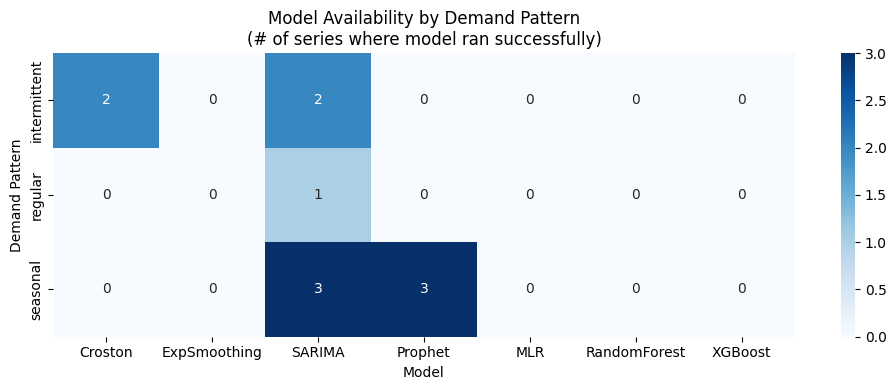

In [8]:
plt.figure(figsize=(10, 4))
sns.heatmap(
    availability,
    annot=True, fmt="d",
    cmap="Blues"
)
plt.title("Model Availability by Demand Pattern\n(# of series where model ran successfully)")
plt.xlabel("Model")
plt.ylabel("Demand Pattern")
plt.tight_layout()
plt.savefig("Figure_ModelAvailability.png", dpi=300, bbox_inches="tight")
plt.show()

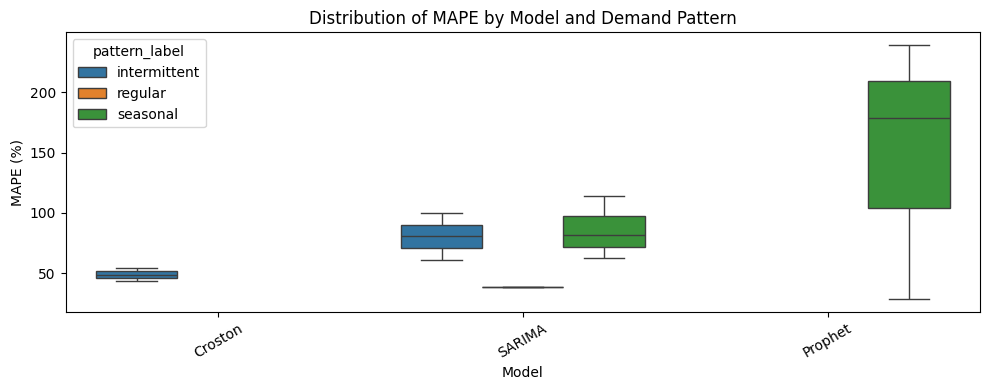

In [9]:
#Boxplot of MAPE per model within each demand type
plt.figure(figsize=(10, 4))
sns.boxplot(
    data=results_df,
    x="model", y="MAPE", hue="pattern_label"
)
plt.title("Distribution of MAPE by Model and Demand Pattern")
plt.ylabel("MAPE (%)")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

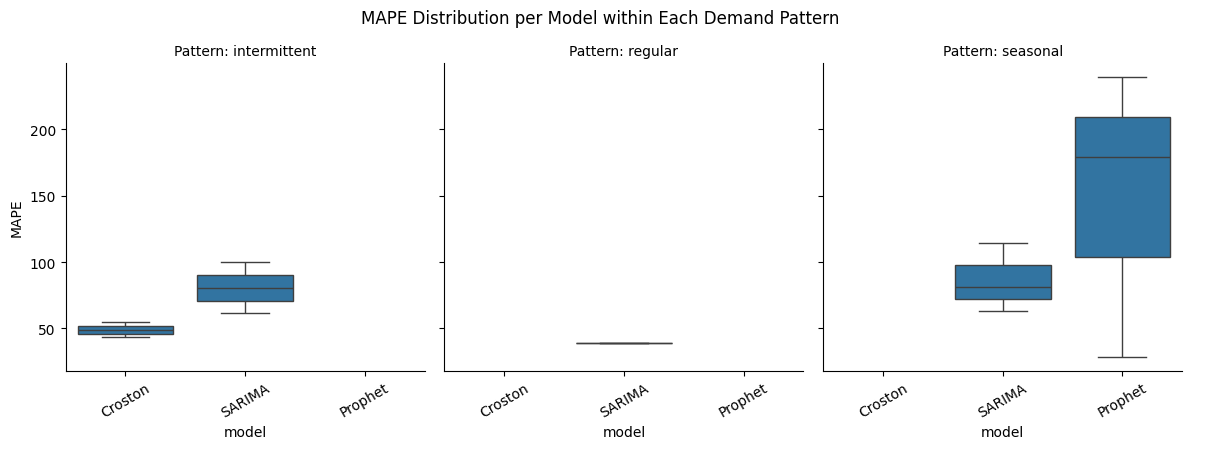

In [10]:
g = sns.catplot(
    data=results_df,
    x="model", y="MAPE",
    col="pattern_label",
    kind="box",
    height=4, aspect=1
)
g.set_titles("Pattern: {col_name}")
g.set_xticklabels(rotation=30)
g.fig.suptitle("MAPE Distribution per Model within Each Demand Pattern", y=1.05)
plt.show()

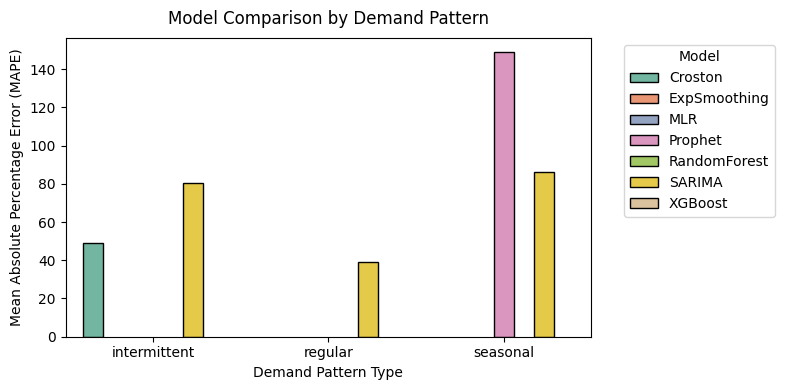

In [19]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=summary,
    x="pattern_label", y="MAPE", hue="model",
    palette="Set2", edgecolor="black"
)

plt.title("Model Comparison by Demand Pattern", fontsize=12, pad=10)
plt.ylabel("Mean Absolute Percentage Error (MAPE)")
plt.xlabel("Demand Pattern Type")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("Figure_ModelPerformance.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# Clean numeric formatting
summary_fmt = summary.copy()
summary_fmt["MAPE"] = summary_fmt["MAPE"].round(3)
summary_fmt["RMSE"] = summary_fmt["RMSE"].round(3)
summary_fmt["MAE"] = summary_fmt["MAE"].round(3)
summary_fmt["sMAPE"] = summary_fmt["sMAPE"].round(3)
summary_fmt["Bias"] = summary_fmt["Bias"].round(3)
summary_fmt["MASE"] = summary_fmt["MASE"].round(3)

# Save as CSV for later formatting in Word/LaTeX
summary_fmt.to_csv("Table_ModelPerformance.csv", index=False)

# Display top few rows nicely
print(summary_fmt.head(10))

   pattern_label         model    MAPE   RMSE    MAE    sMAPE   Bias   MASE
0   intermittent       Croston  48.864  0.522  0.519  134.179  0.011  1.220
1   intermittent  ExpSmoothing     NaN    NaN    NaN      NaN    NaN    NaN
4   intermittent           MLR     NaN    NaN    NaN      NaN    NaN    NaN
3   intermittent       Prophet     NaN    NaN    NaN      NaN    NaN    NaN
5   intermittent  RandomForest     NaN    NaN    NaN      NaN    NaN    NaN
2   intermittent        SARIMA  80.633  1.237  1.069  159.164 -0.274  2.214
6   intermittent       XGBoost     NaN    NaN    NaN      NaN    NaN    NaN
7        regular       Croston     NaN    NaN    NaN      NaN    NaN    NaN
8        regular  ExpSmoothing     NaN    NaN    NaN      NaN    NaN    NaN
11       regular           MLR     NaN    NaN    NaN      NaN    NaN    NaN


In [13]:
#win count analysis
winners = (
    results_df
    .loc[results_df.groupby(["StoreId", "ItemId", "pattern_label"])["MAPE"].idxmin()]
    [["StoreId", "ItemId", "pattern_label", "model"]]
)

winners.head()

win_counts = (
    winners
    .groupby(["pattern_label", "model"])
    .size()
    .reset_index(name="n_wins")
    .sort_values(["pattern_label", "n_wins"], ascending=[True, False])
)

win_counts

,pattern_label,model,n_wins
0,intermittent,Croston,2
1,regular,SARIMA,1
3,seasonal,SARIMA,2
2,seasonal,Prophet,1


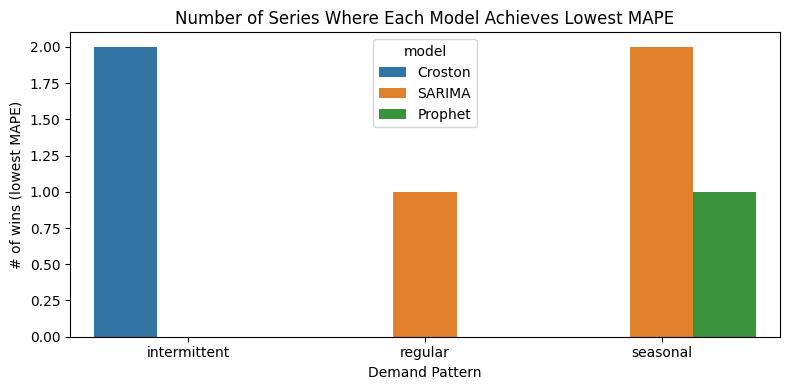

In [14]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=win_counts,
    x="pattern_label", y="n_wins", hue="model"
)
plt.title("Number of Series Where Each Model Achieves Lowest MAPE")
plt.ylabel("# of wins (lowest MAPE)")
plt.xlabel("Demand Pattern")
plt.tight_layout()
plt.show()


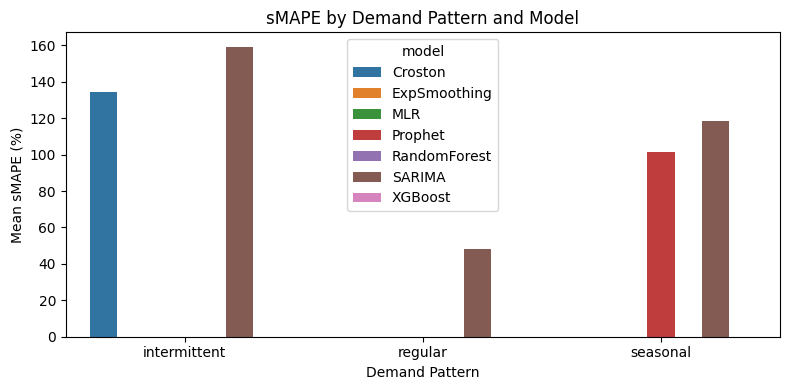

In [15]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=summary,
    x="pattern_label", y="sMAPE", hue="model"
)
plt.title("sMAPE by Demand Pattern and Model")
plt.ylabel("Mean sMAPE (%)")
plt.xlabel("Demand Pattern")
plt.tight_layout()
plt.show()

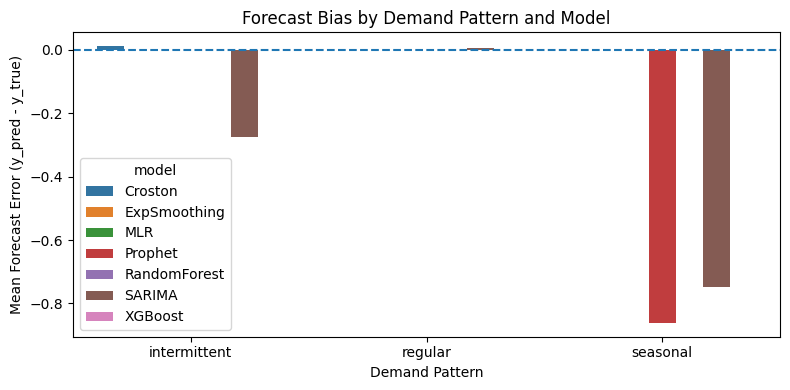

In [16]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=summary,
    x="pattern_label", y="Bias", hue="model"
)
plt.axhline(0, linestyle="--")
plt.title("Forecast Bias by Demand Pattern and Model")
plt.ylabel("Mean Forecast Error (y_pred - y_true)")
plt.xlabel("Demand Pattern")
plt.tight_layout()
plt.show()
